### **Importing Datasets**

In [1]:
# extracting the compressed Dataset
from zipfile import ZipFile
dataset = '/content/Pan Card Detection.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [2]:
!ls

'pan_card_data(536).json'  'Pan Card Detection.zip'
'Pan Card Detection'	    sample_data


## **Install and Import Dependencies**

In [3]:
!pip install python-Levenshtein

In [4]:
!pip install openbharatocr

In [5]:
import openbharatocr
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import cv2
import os
import re
import networkx as nx
from Levenshtein import ratio
from difflib import SequenceMatcher

## **Read in single Image & Draw Results**



In [10]:
Image_path = '/content/Pan Card Detection/pan card(949)/01d05582-5847b2009867b37d04746fa1_pan.jpg'
front_result = openbharatocr.pan(Image_path)
front_result

{'Full Name': 'ABHISHEK PATHANIA',
 "Parent's Name": 'VIJAY PATHANIA',
 'Date of Birth': '15/40/1993',
 'PAN Number': 'DCWPP9916H'}

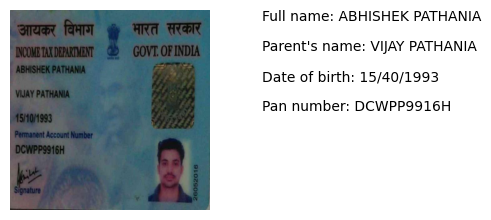

In [11]:
img = cv2.imread(Image_path)

# Resize image (scale down)
img = cv2.resize(img, None, fx=0.7, fy=0.7)  # reduce to 70%

# Extract Aadhaar details
result = openbharatocr.pan(Image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(
    1, 2,
    figsize=(4,2),
    gridspec_kw={'width_ratios': [3, 1]}
)

# Aadhaar image
ax[0].imshow(img_rgb)
ax[0].axis("off")

# Text panel
ax[1].axis("off")

y = 1.0
for key, value in result.items():
    ax[1].text(0.0, y, f"{key.capitalize()}: {value}", fontsize=10, va='top')
    y -= 0.15

plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.02)

plt.show()

In [12]:
Image_path = '/content/Pan Card Detection/pan card(949)/1a659cad-5875f38a9ecee3a41d6467d2_pan.jpg'
result = openbharatocr.pan(Image_path)
result

{'Full Name': '',
 "Parent's Name": '',
 'Date of Birth': '',
 'PAN Number': 'CITPM6035L'}

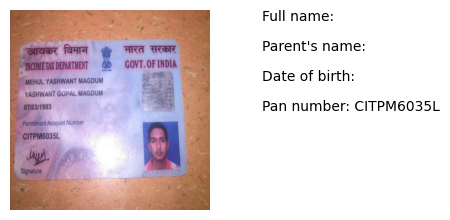

In [13]:
img = cv2.imread(Image_path)

# Extract Aadhaar details
result = openbharatocr.pan(Image_path)

# Resize image (scale down)
img = cv2.resize(img, None, fx=0.7, fy=0.7)  # reduce to 70%

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(
    1, 2,
    figsize=(4,2),
    gridspec_kw={'width_ratios': [3, 1]}
)

# Aadhaar image
ax[0].imshow(img_rgb)
ax[0].axis("off")

# Text panel
ax[1].axis("off")

y = 1.0
for key, value in result.items():
    ax[1].text(0.0, y, f"{key.capitalize()}: {value}", fontsize=10, va='top')
    y -= 0.15

plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.02)

plt.show()

## **Reading all Images & Draw Results**



In [16]:
folder_path = "/content/Pan Card Detection/pan card(949)"

all_records = []

for file in os.listdir(folder_path):

    if file.lower().endswith((".jpg", ".jpeg", ".png")):

        image_path = os.path.join(folder_path, file)

        try:
            result = openbharatocr.pan(image_path)

            record = {
                "Name": result.get("Full Name"),
                "Parent's Name": result.get("Parent's Name"),
                "Date of Birth": result.get("Date of Birth"),
                "PAN Number": result.get("PAN Number")
            }

            all_records.append(record)

        except Exception as e:
            print(f"Error processing {file}: {e}")


Name: SET C RNIN
Parent's Name: 
Date of Birth: 
PAN Number: 

Name: YOGENDRA DASHRATHSINGH
Parent's Name: YOGENDRA DASHRATHSINGH
Date of Birth: 06/02/1994
PAN Number: BFRPC4243Q

Name: AKASH KUWAR
Parent's Name: AUARDEEP PRASAD
Date of Birth: 
PAN Number: 

Name: GCAPDOBEER
Parent's Name: 
Date of Birth: 
PAN Number: 

Name: MOHD YUSUF KHAN
Parent's Name: 
Date of Birth: 
PAN Number: ACSPK8262C

Name: BIRR
Parent's Name: VIRJIBHAI PREMJIBHAL CHAVDA OER
Date of Birth: 15/07/1951
PAN Number: APCPC2540L

Name: KALPANA VINOD BALSARA
Parent's Name: 
Date of Birth: 27-12-1966
PAN Number: AFOPB3080J

Name: 
Parent's Name: 
Date of Birth: 
PAN Number: 

Name: 
Parent's Name: 
Date of Birth: 
PAN Number: 

Name: SANJEEV KUMAR
Parent's Name: BARU RAM
Date of Birth: 06/06/1973
PAN Number: DYFPK6749J

Name: 
Parent's Name: 
Date of Birth: 
PAN Number: 

Name: NANIKRAM PITAMBER HASSANI
Parent's Name: 
Date of Birth: 
PAN Number: 

Name: NOONAN DERRMENT
Parent's Name: MILAN JANA
Date of Birth: 
PAN

In [18]:
print(len(all_records))

949


In [19]:
# Print extracted details
for rec in all_records[:10]:
    for key, value in rec.items():
        if key != "file_name":
            print(f"{key}: {value}")
    print()

Name: SET C RNIN
Parent's Name: 
Date of Birth: 
PAN Number: 

Name: YOGENDRA DASHRATHSINGH
Parent's Name: YOGENDRA DASHRATHSINGH
Date of Birth: 06/02/1994
PAN Number: BFRPC4243Q

Name: AKASH KUWAR
Parent's Name: AUARDEEP PRASAD
Date of Birth: 
PAN Number: 

Name: GCAPDOBEER
Parent's Name: 
Date of Birth: 
PAN Number: 

Name: MOHD YUSUF KHAN
Parent's Name: 
Date of Birth: 
PAN Number: ACSPK8262C

Name: BIRR
Parent's Name: VIRJIBHAI PREMJIBHAL CHAVDA OER
Date of Birth: 15/07/1951
PAN Number: APCPC2540L

Name: KALPANA VINOD BALSARA
Parent's Name: 
Date of Birth: 27-12-1966
PAN Number: AFOPB3080J

Name: 
Parent's Name: 
Date of Birth: 
PAN Number: 

Name: 
Parent's Name: 
Date of Birth: 
PAN Number: 

Name: SANJEEV KUMAR
Parent's Name: BARU RAM
Date of Birth: 06/06/1973
PAN Number: DYFPK6749J



### **Data Cleaning**

In [24]:
# Lists to store records with missing fields
missing_name = []
missing_parent = []
missing_dob = []
missing_pan = []

# Check each record
for rec in all_records:
    if not rec.get("Name") or rec.get("Name").strip() == "":
        missing_name.append(rec)
    if not rec.get("Parent's Name") or rec.get("Parent's Name").strip() == "":
        missing_parent.append(rec)
    if not rec.get("Date of Birth") or rec.get("Date of Birth").strip() == "":
        missing_dob.append(rec)
    if not rec.get("PAN Number") or rec.get("PAN Number").strip() == "":
        missing_pan.append(rec)


In [25]:
print(f"Missing Name: {len(missing_name)}")
print(f"Missing Parent's Name: {len(missing_parent)}")
print(f"Missing Date of Birth: {len(missing_dob)}")
print(f"Missing PAN Number: {len(missing_pan)}")

Missing Name: 340
Missing Parent's Name: 508
Missing Date of Birth: 700
Missing PAN Number: 640


Since OCR has a lot of missing records we are training the model on the records(stored in json file) extracted from the samples using CLAUDE AI

In [27]:
import json

# Open the JSON file and load its content
with open('/content/pan_card_data(536).json', 'r') as f:
    all_records = json.load(f)

print(f"Total PAN records loaded: {len(all_records)}")
print("First record:", all_records[0])

Total PAN records loaded: 536
First record: {'Name': 'RAJ KUMAR', "Parent's Name": 'SODAN SINGH', 'Date of Birth': '18/07/1995', 'PAN Number': 'DNIPK0430E'}


In [28]:
# Print last 5 records
for i, record in enumerate(all_records[-5:], 1):
    record_no_file = {k: v for k, v in record.items() if k != "_filename"}
    print(f"Record {i}: {record_no_file}")

Record 1: {'Name': 'HRITTIK BASAK', "Parent's Name": 'DOLAN BASAK', 'Date of Birth': '18/06/2000', 'PAN Number': 'EHWPB6522H'}
Record 2: {'Name': 'AKSHAY JANA', "Parent's Name": 'AJIT JANA', 'Date of Birth': '18/09/1992', 'PAN Number': 'AVQPJ1395N'}
Record 3: {'Name': 'CHETAN KUMAR', "Parent's Name": 'BHUNESHWAR PRASAD', 'Date of Birth': '15/10/1994', 'PAN Number': 'CVMPK1047E'}
Record 4: {'Name': 'P RAKESH SHARMA', "Parent's Name": 'PERUMAL', 'Date of Birth': '24/01/1992', 'PAN Number': 'BVYPR6433A'}
Record 5: {'Name': 'AMBAR RAJ', "Parent's Name": 'KRISHNA KUMAR', 'Date of Birth': '10/05/2005', 'PAN Number': 'GSNPR7512F'}


## **Visualizing Network graph for any similar nodes**

In [29]:
# Function to compute similarity
def ratio(a, b):
    return SequenceMatcher(None, a, b).ratio()

# Clean PAN function
def clean_pan(p):
    if not p:
        return ""
    return p.replace(" ", "").strip()

# Initialize graph
G = nx.Graph()

# Add nodes
for i, rec in enumerate(all_records):
    G.add_node(i,
               name=rec.get("Name"),
               parent_name=rec.get("Parent's Name"),
               dob=rec.get("Date of Birth"),
               pan=rec.get("PAN Number")
              )

# Create edges based on similarity
for i in range(len(all_records)):
    for j in range(i+1, len(all_records)):
        r1 = all_records[i]
        r2 = all_records[j]

        reasons = []

        # PAN similarity
        p1 = clean_pan(r1.get("PAN Number"))
        p2 = clean_pan(r2.get("PAN Number"))
        if p1 and p1 == p2:
            reasons.append("same_pan")

        # Name similarity
        if r1.get("Name") and r2.get("Name"):
            sim = ratio(r1["Name"].lower(), r2["Name"].lower())
            if sim > 0.7:
                reasons.append("similar_name")

        # Parent's Name similarity
        if r1.get("Parent's Name") and r2.get("Parent's Name"):
            sim = ratio(r1["Parent's Name"].lower(), r2["Parent's Name"].lower())
            if sim > 0.7:
                reasons.append("similar_parent_name")

        # DOB similarity
        if r1.get("Date of Birth") and r1.get("Date of Birth") == r2.get("Date of Birth"):
            reasons.append("same_dob")

        # Name + DOB match
        if r1.get("Name") == r2.get("Name") and r1.get("Date of Birth") == r2.get("Date of Birth"):
            reasons.append("name_dob_match")

        # Add edge if any similarity found
        if reasons:
            G.add_edge(i, j, reason=",".join(reasons))

# Node colors based on number of connections
node_colors = []
for node in G.nodes():
    if G.degree[node] >= 2:
        node_colors.append("red")      # suspicious cluster
    elif G.degree[node] == 1:
        node_colors.append("orange")   # possible link
    else:
        node_colors.append("skyblue")  # isolated

print("Graph created with nodes:", G.number_of_nodes(), "and edges:", G.number_of_edges())

Graph created with nodes: 536 and edges: 376


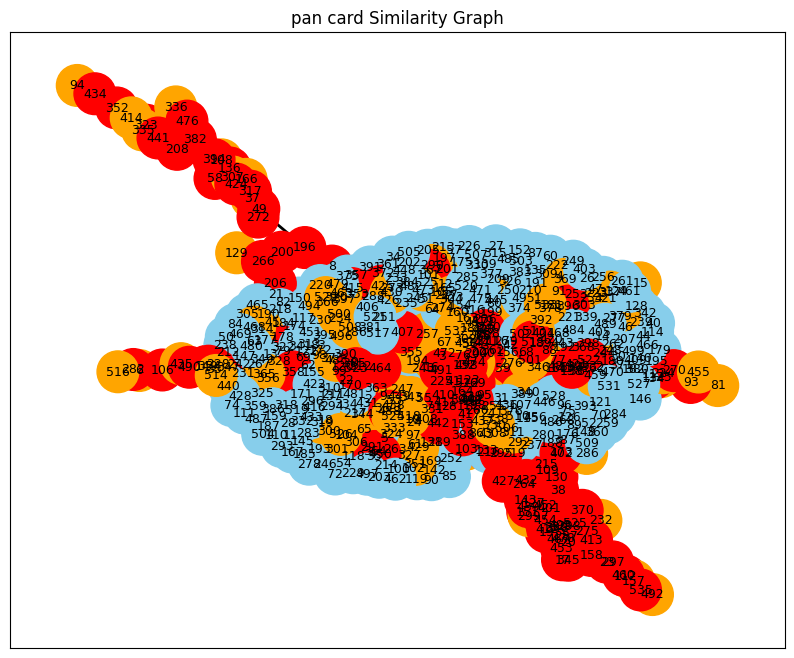

In [30]:
plt.figure(figsize=(10,8))

pos = nx.spring_layout(G, k=1.2, seed=42)  # spread nodes more

nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=900
)

nx.draw_networkx_edges(
    G, pos,
    edge_color="black",
    width=2
)

nx.draw_networkx_labels(
    G, pos,
    font_size=9
)

plt.title("pan card Similarity Graph")
plt.show()

In [31]:
print("Number of edges:", G.number_of_edges())

Number of edges: 376


## **Training the GNN model**

**Install libraries**

In [33]:
!pip install sentence-transformers torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.3 MB/s eta 0:00:00


In [34]:
!pip install torch-geometric

**Import libraries**

In [35]:
import torch
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer
from torch_geometric.utils import from_networkx
from torch_geometric.nn import GCNConv
from sklearn.preprocessing import StandardScaler

In [36]:
data = from_networkx(G)

In [37]:
# Convert Names and Parent's Names to embeddings
model_embed = SentenceTransformer("all-MiniLM-L6-v2")

names = [rec["Name"] if rec.get("Name") else "" for rec in all_records]
parent_names = [rec["Parent's Name"] if rec.get("Parent's Name") else "" for rec in all_records]

name_vectors = model_embed.encode(names)
parent_vectors = model_embed.encode(parent_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [38]:
#Extract numeric features
numeric_features = []

for rec in all_records:

    # Gender not present in PAN, use 3 = Unknown
    gender = 3

    # DOB extraction
    day = 0
    month = 0
    year = 0
    dob = rec.get("Date of Birth", "")

    if dob and "/" in dob:
        try:
            d, m, y = dob.split("/")
            day = int(d)
            month = int(m)
            year = int(y)
        except:
            pass
    elif dob and len(dob) == 4:
        try:
            year = int(dob)
        except:
            pass

    # PAN number letters → numeric
    pan_digits = [0]*10
    pan = rec.get("PAN Number", "")
    if pan:
        pan_clean = pan.replace(" ","")
        pan_digits = []
        for c in pan_clean:
            if c.isdigit():
                pan_digits.append(int(c))
            elif c.isalpha():
                pan_digits.append(ord(c.upper()) - 64)  # A=1 … Z=26
        # Pad/truncate to 10
        pan_digits = pan_digits[:10] + [0]*(10 - len(pan_digits))

    numeric_features.append(
        [gender, day, month, year] + pan_digits
    )

numeric_features = np.array(numeric_features)


In [39]:
# 3️ Combine name + parent embeddings + numeric features
features = np.concatenate([name_vectors, parent_vectors, numeric_features], axis=1)

In [40]:
# 4️ Normalize features
scaler = StandardScaler()
features = scaler.fit_transform(features)

In [41]:
# 5️ Convert to PyTorch tensor
X = torch.tensor(features, dtype=torch.float)

In [42]:
# 6️ Assign features to your PyG graph
data = from_networkx(G)
data.x = X

In [43]:
print("PAN card feature tensor shape with parent embeddings:", data.x.shape)

PAN card feature tensor shape with parent embeddings: torch.Size([536, 782])


In [49]:
# Show feature vector for the first record
record_index = 0
print(f"Feature vector for record {record_index+1} ({all_records[record_index]}):\n")
print(X[record_index])

Feature vector for record 1 ({'Name': 'RAJ KUMAR', "Parent's Name": 'SODAN SINGH', 'Date of Birth': '18/07/1995', 'PAN Number': 'DNIPK0430E'}):

tensor([ 1.0303e+00, -4.9223e-01,  7.5549e-02, -8.2094e-02,  1.6454e+00,
        -7.2052e-01,  8.3020e-01, -1.1187e-02, -6.8215e-01,  1.5781e+00,
        -7.9304e-01, -9.5289e-02,  1.2631e+00, -2.5858e-01,  1.3970e+00,
         4.2725e-01,  1.7527e-01, -4.5026e-01,  1.4026e+00, -1.1041e+00,
        -2.0249e-01,  1.4533e-01, -2.6549e+00, -1.8140e+00, -1.9792e-01,
         9.9105e-02, -2.0218e-01, -1.5581e+00, -1.3745e+00,  7.8363e-02,
        -9.4028e-01,  2.0122e-01, -2.8974e-01, -1.6569e-01, -3.8750e-02,
        -1.8809e+00, -8.3903e-02,  2.1773e+00,  1.3449e-01, -1.5205e+00,
        -3.1233e-02, -3.5552e-01,  9.6763e-01,  8.7823e-01,  1.1645e+00,
        -1.3745e-01,  1.6188e+00, -1.8172e+00,  5.3129e-01,  7.3093e-01,
        -2.6421e-01,  1.9425e+00,  2.0392e-01,  7.0233e-01, -7.8591e-01,
        -3.2757e-01,  2.2369e-02,  1.4626e-01,  3.05

In [45]:
# 1️ Define GNN model
class GNN(torch.nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 128)  # first layer
        self.conv2 = GCNConv(128, 64)           # second layer

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

In [46]:
# 2️ Initialize model
in_dim = X.shape[1]  # input dimension = size of feature vector
model = GNN(in_channels=in_dim)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [47]:

# 3️ Train the model
for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = torch.mean(out**2)   # unsupervised anomaly detection
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 0.7541072964668274
Epoch: 20 Loss: 0.019069897010922432
Epoch: 40 Loss: 0.0025431716348975897
Epoch: 60 Loss: 0.0005430934252217412
Epoch: 80 Loss: 0.0002191625244449824
Epoch: 100 Loss: 0.0001308666105614975
Epoch: 120 Loss: 9.292922914028168e-05
Epoch: 140 Loss: 7.08290099282749e-05
Epoch: 160 Loss: 5.613643952528946e-05
Epoch: 180 Loss: 4.5720422349404544e-05


In [50]:
# 4️ Compute anomaly scores
model.eval()
with torch.no_grad():
    embeddings = model(data.x, data.edge_index)
    scores = torch.norm(embeddings, dim=1)  # L2 norm as anomaly score

# 5️ Print anomaly scores for each record
print("\n--- PAN Record Anomaly Scores ---\n")
for i, s in enumerate(scores):
    print(f"Record {i} ({all_records[i]}): Anomaly Score = {float(s):.4f}")


--- PAN Record Anomaly Scores ---

Record 0 ({'Name': 'RAJ KUMAR', "Parent's Name": 'SODAN SINGH', 'Date of Birth': '18/07/1995', 'PAN Number': 'DNIPK0430E'}): Anomaly Score = 0.0813
Record 1 ({'Name': 'MOUMITA PAYRA DAS', "Parent's Name": 'SWAPAN PAYRA', 'Date of Birth': '27/07/1991', 'PAN Number': 'DQVPP6174C'}): Anomaly Score = 0.0378
Record 2 ({'Name': 'SANJAY GHOSH', "Parent's Name": 'BIPAD TARAN GHOSH', 'Date of Birth': '02/01/1974', 'PAN Number': 'BXKPG6694L'}): Anomaly Score = 0.0139
Record 3 ({'Name': 'RAKESH KUMAR RATHORE', "Parent's Name": 'GAJODHAR LAL', 'Date of Birth': '01/01/1984', 'PAN Number': 'EDRPR6212M'}): Anomaly Score = 0.0486
Record 4 ({'Name': 'MAHESH SADHU', "Parent's Name": 'PRADIP SADHU', 'Date of Birth': '03/01/1997', 'PAN Number': 'MLLPS3496J'}): Anomaly Score = 0.0033
Record 5 ({'Name': 'GARLAPATI SAI KIRAN REDDY', "Parent's Name": 'VENKAT REDDY GARLAPATI', 'Date of Birth': '28/11/1996', 'PAN Number': 'CEFPG4334E'}): Anomaly Score = 0.0033
Record 6 ({'Nam

In [51]:
# 6️ Save the trained model
torch.save(model.state_dict(), "pan_gnn_model.pth")

In [52]:
# 7️ Load the model later
model.load_state_dict(torch.load("pan_gnn_model.pth"))

<All keys matched successfully>

### **Testing on a Single sample**

In [54]:
# Select one pan card record from the dataset
record_index = 0
rec = all_records[record_index]
print("Testing record:")

Testing record:


In [55]:
# Extract numeric features (same logic as training)
def extract_numeric_features_pan(rec):
    # Gender placeholder for PAN
    gender = 3  # unknown

    # DOB extraction
    day, month, year = 0, 0, 0
    dob = rec.get("Date of Birth", "")
    if dob and "/" in dob:
        parts = dob.split("/")
        if len(parts) == 3:
            try:
                day, month, year = map(int, parts)
            except:
                pass
    elif dob and len(dob) == 4:
        try:
            year = int(dob)
        except:
            pass

    # PAN numeric encoding (letters → numbers, digits as is)
    pan_digits = [0]*10
    pan = rec.get("PAN Number", "")
    if pan:
        pan_clean = pan.replace(" ","")
        pan_digits = []
        for c in pan_clean:
            if c.isdigit():
                pan_digits.append(int(c))
            elif c.isalpha():
                pan_digits.append(ord(c.upper()) - 64)
        pan_digits = pan_digits[:10] + [0]*(10 - len(pan_digits))

    numeric = [gender, day, month, year] + pan_digits
    return np.array(numeric)

# Convert Name and Parent Name to embeddings
model_embed = SentenceTransformer("all-MiniLM-L6-v2")
names = [rec.get("Name", "")]
parent_names = [rec.get("Parent's Name", "")]
name_vector = model_embed.encode(names)
parent_vector = model_embed.encode(parent_names)

# Extract numeric features
numeric = extract_numeric_features_pan(rec).reshape(1, -1)

# Combine embeddings + numeric features (matching training logic)
features_combined = np.concatenate([name_vector, parent_vector, numeric], axis=1)

# Normalize using previously trained scaler
features_scaled = scaler.transform(features_combined)

# Convert to tensor
sample_x = torch.tensor(features_scaled, dtype=torch.float)

# Create empty edge_index for single isolated node
empty_edge_index = torch.empty((2, 0), dtype=torch.long)

# Compute anomaly score
model.eval()
with torch.no_grad():
    embeddings = model(sample_x, empty_edge_index)
    score = torch.norm(embeddings, dim=1).item()

print("Anomaly Score:", score)

# Decide normal vs suspicious
threshold =   # adjust based on your training
if score > threshold:
    print("☑ Suspicious PAN Record")
else:
    print("✅ Normal PAN Record")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Anomaly Score: 2.736914873123169
✅ Normal PAN Record


In [56]:
print(rec)

{'Name': 'RAJ KUMAR', "Parent's Name": 'SODAN SINGH', 'Date of Birth': '18/07/1995', 'PAN Number': 'DNIPK0430E'}


**Observing top 5 related nodes to input**

In [ ]:
# In general how we should put threshold
scores_np = scores.numpy()
print("Max score in training:", scores_np.max())
print("Mean score:", scores_np.mean())
print("Std:", scores_np.std())
threshold = scores_np.mean() + 3*scores_np.std()
print(threshold)

Max score in training: 0.113081336
Mean score: 0.039420787
Std: 0.029662393
0.12840796634554863


In [57]:
# Print details of the input PAN record
print("Input PAN Record:")
print(rec)
print()

# Normalize vectors for cosine similarity
sample_norm = F.normalize(sample_x, dim=1)
nodes_norm = F.normalize(data.x, dim=1)

# Compute similarity scores
similarities = torch.mm(sample_norm, nodes_norm.T)

# Get top 5 most similar nodes
top_k = 0.1
values, indices = torch.topk(similarities, top_k)

print("Most similar PAN records in dataset:")

for i in range(top_k):
    node_id = indices[0][i].item()
    sim_score = values[0][i].item()
    rec_sim = all_records[node_id]
    print(f"Node {node_id}  Similarity: {sim_score:.4f}")
    print(rec_sim)  # Simply print the full dictionary
    print()

Input PAN Record:
{'Name': 'RAJ KUMAR', "Parent's Name": 'SODAN SINGH', 'Date of Birth': '18/07/1995', 'PAN Number': 'DNIPK0430E'}

Most similar PAN records in dataset:
Node 0  Similarity: 1.0000
{'Name': 'RAJ KUMAR', "Parent's Name": 'SODAN SINGH', 'Date of Birth': '18/07/1995', 'PAN Number': 'DNIPK0430E'}

Node 69  Similarity: 0.5191
{'Name': 'MANOJ KUMAR', "Parent's Name": 'MAHA SINGH', 'Date of Birth': '21/10/1988', 'PAN Number': 'BMCPM7422D'}

Node 149  Similarity: 0.4841
{'Name': 'SONIA SINGH', "Parent's Name": 'RANDHIR SINGH', 'Date of Birth': '05/11/1983', 'PAN Number': 'GJSPS7711H'}

Node 206  Similarity: 0.4678
{'Name': 'ABHISHEK KUMAR SINGH', "Parent's Name": 'RAJ KUMAR SINGH', 'Date of Birth': '10/06/1992', 'PAN Number': 'DPTPS4099C'}

Node 184  Similarity: 0.4596
{'Name': 'PRADIP KUMAR SINGH', "Parent's Name": 'RAMDRASHAN SINGH', 'Date of Birth': '15/04/1987', 'PAN Number': 'CPTPS3853K'}

